## New section plots with updated data and years

In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy

from importlib import reload
import SO_tools as tools; reload(tools)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SO_tools' from '/Users/lilah/Documents/IBIS_Project/SO_tools.py'>

In [2]:
df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/newest_bgc_profiles_ext_alltime.csv')
# df_new = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv') # for stevie


/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_1858/3273616132.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/newest_bgc_profiles_ext_alltime.csv')


In [3]:
#convert to datetime
df_new['DATE'] = pd.to_datetime(df_new['DATE'],format = 'mixed')
df_new = df_new.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon 

#fix lat lon values with '--' (replace with nan) 
df_new['LATITUDE'] = pd.to_numeric(df_new['LATITUDE'], errors='coerce')
df_new['LONGITUDE'] = pd.to_numeric(df_new['LONGITUDE'], errors='coerce')

In [4]:
# Condition 1: July-Dec 2014
cond1 = (df_new['year'] == 2019) & (df_new['month'] >= 5)

# Condition 2: Jan-June 2015
cond2 = (df_new['year'] == 2020) & (df_new['month'] <= 5)


# Combine them with "OR" (|)
subset_df = df_new[cond1 | cond2]


float_data = df_new[df_new['WMOID'].isin([5905379])]
float_data

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,DOWNWELLING_PAR_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
888967,888967,889947,5905379,2,A,2018-02-14 05:22:59.000568+00:00,1,-65.232,151.604,1,...,NaN,2018,2,2017-2018,NaN,NaN,NaN,NaN,NaN,4.78
888968,888968,889948,5905379,2,A,2018-02-14 05:22:59.000568+00:00,1,-65.232,151.604,1,...,NaN,2018,2,2017-2018,NaN,NaN,NaN,NaN,NaN,4.78
888969,888969,889949,5905379,2,A,2018-02-14 05:22:59.000568+00:00,1,-65.232,151.604,1,...,NaN,2018,2,2017-2018,NaN,NaN,NaN,NaN,NaN,4.78
888970,888970,889950,5905379,2,A,2018-02-14 05:22:59.000568+00:00,1,-65.232,151.604,1,...,NaN,2018,2,2017-2018,NaN,NaN,NaN,NaN,NaN,4.78
888971,888971,889951,5905379,2,A,2018-02-14 05:22:59.000568+00:00,1,-65.232,151.604,1,...,NaN,2018,2,2017-2018,NaN,NaN,NaN,NaN,NaN,4.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970831,970831,971811,5905379,149,A,2022-03-02 13:48:12.001464+00:00,1,-63.131,164.846,1,...,NaN,2022,3,2021-2022,NaN,NaN,NaN,NaN,NaN,2.79
970832,970832,971812,5905379,149,A,2022-03-02 13:48:12.001464+00:00,1,-63.131,164.846,1,...,NaN,2022,3,2021-2022,NaN,NaN,NaN,NaN,NaN,2.79
970833,970833,971813,5905379,149,A,2022-03-02 13:48:12.001464+00:00,1,-63.131,164.846,1,...,NaN,2022,3,2021-2022,NaN,NaN,NaN,NaN,NaN,2.79
970834,970834,971814,5905379,149,A,2022-03-02 13:48:12.001464+00:00,1,-63.131,164.846,1,...,NaN,2022,3,2021-2022,NaN,NaN,NaN,NaN,NaN,2.79


In [13]:
df2 = subset_df[subset_df['WMOID'].isin([5905379])]

# # regridding data (from oneargopy code) -----------

time_values = pd.to_datetime(df2['DATE']).values
pres_values = df2['PRES'].values
param_values = df2['TEMP_ADJUSTED'].values
# # Remove NaN values
valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values) # TROUBLEMAKER for all values variables
time_values = time_values[valid_indices]
pres_values = pres_values[valid_indices] # pres_values stops working here
# param_values = param_values[valid_indices]
# # Convert time_values to float because it makes gridding data easier
# time_values_num = mdates.date2num(time_values)
# # Unique values for creating grids
# unique_times_num = np.unique(time_values_num)
print(pres_values)

# confused why valid_indices is making pres_values nonexistent because pres_values has vaules (not NaNs) until that line and that
# line should only change NaN values

[]


<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_99471/640477414.py:108: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 322,  df1=subset_df, title = 'B. Dissolved Oxygen', variable='DOXY_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.ice')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_99471/640477414.py:110: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 324,  df1=subset_df, title = 'D. Nitrate', variable='NITRATE_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.tempo')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_99471/640477414.py:108: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 322,  df1=subset_df, title = 'B. Dissolved Oxygen', variable='DOXY_ADJUSTED', cbarlab = f'$\mu$mol/

ValueError: For X (0) and Y (1991) with flat shading, A should have shape (1990, -1, 3) or (1990, -1, 4) or (1990, -1) or (-1990,), not (1990, 0)

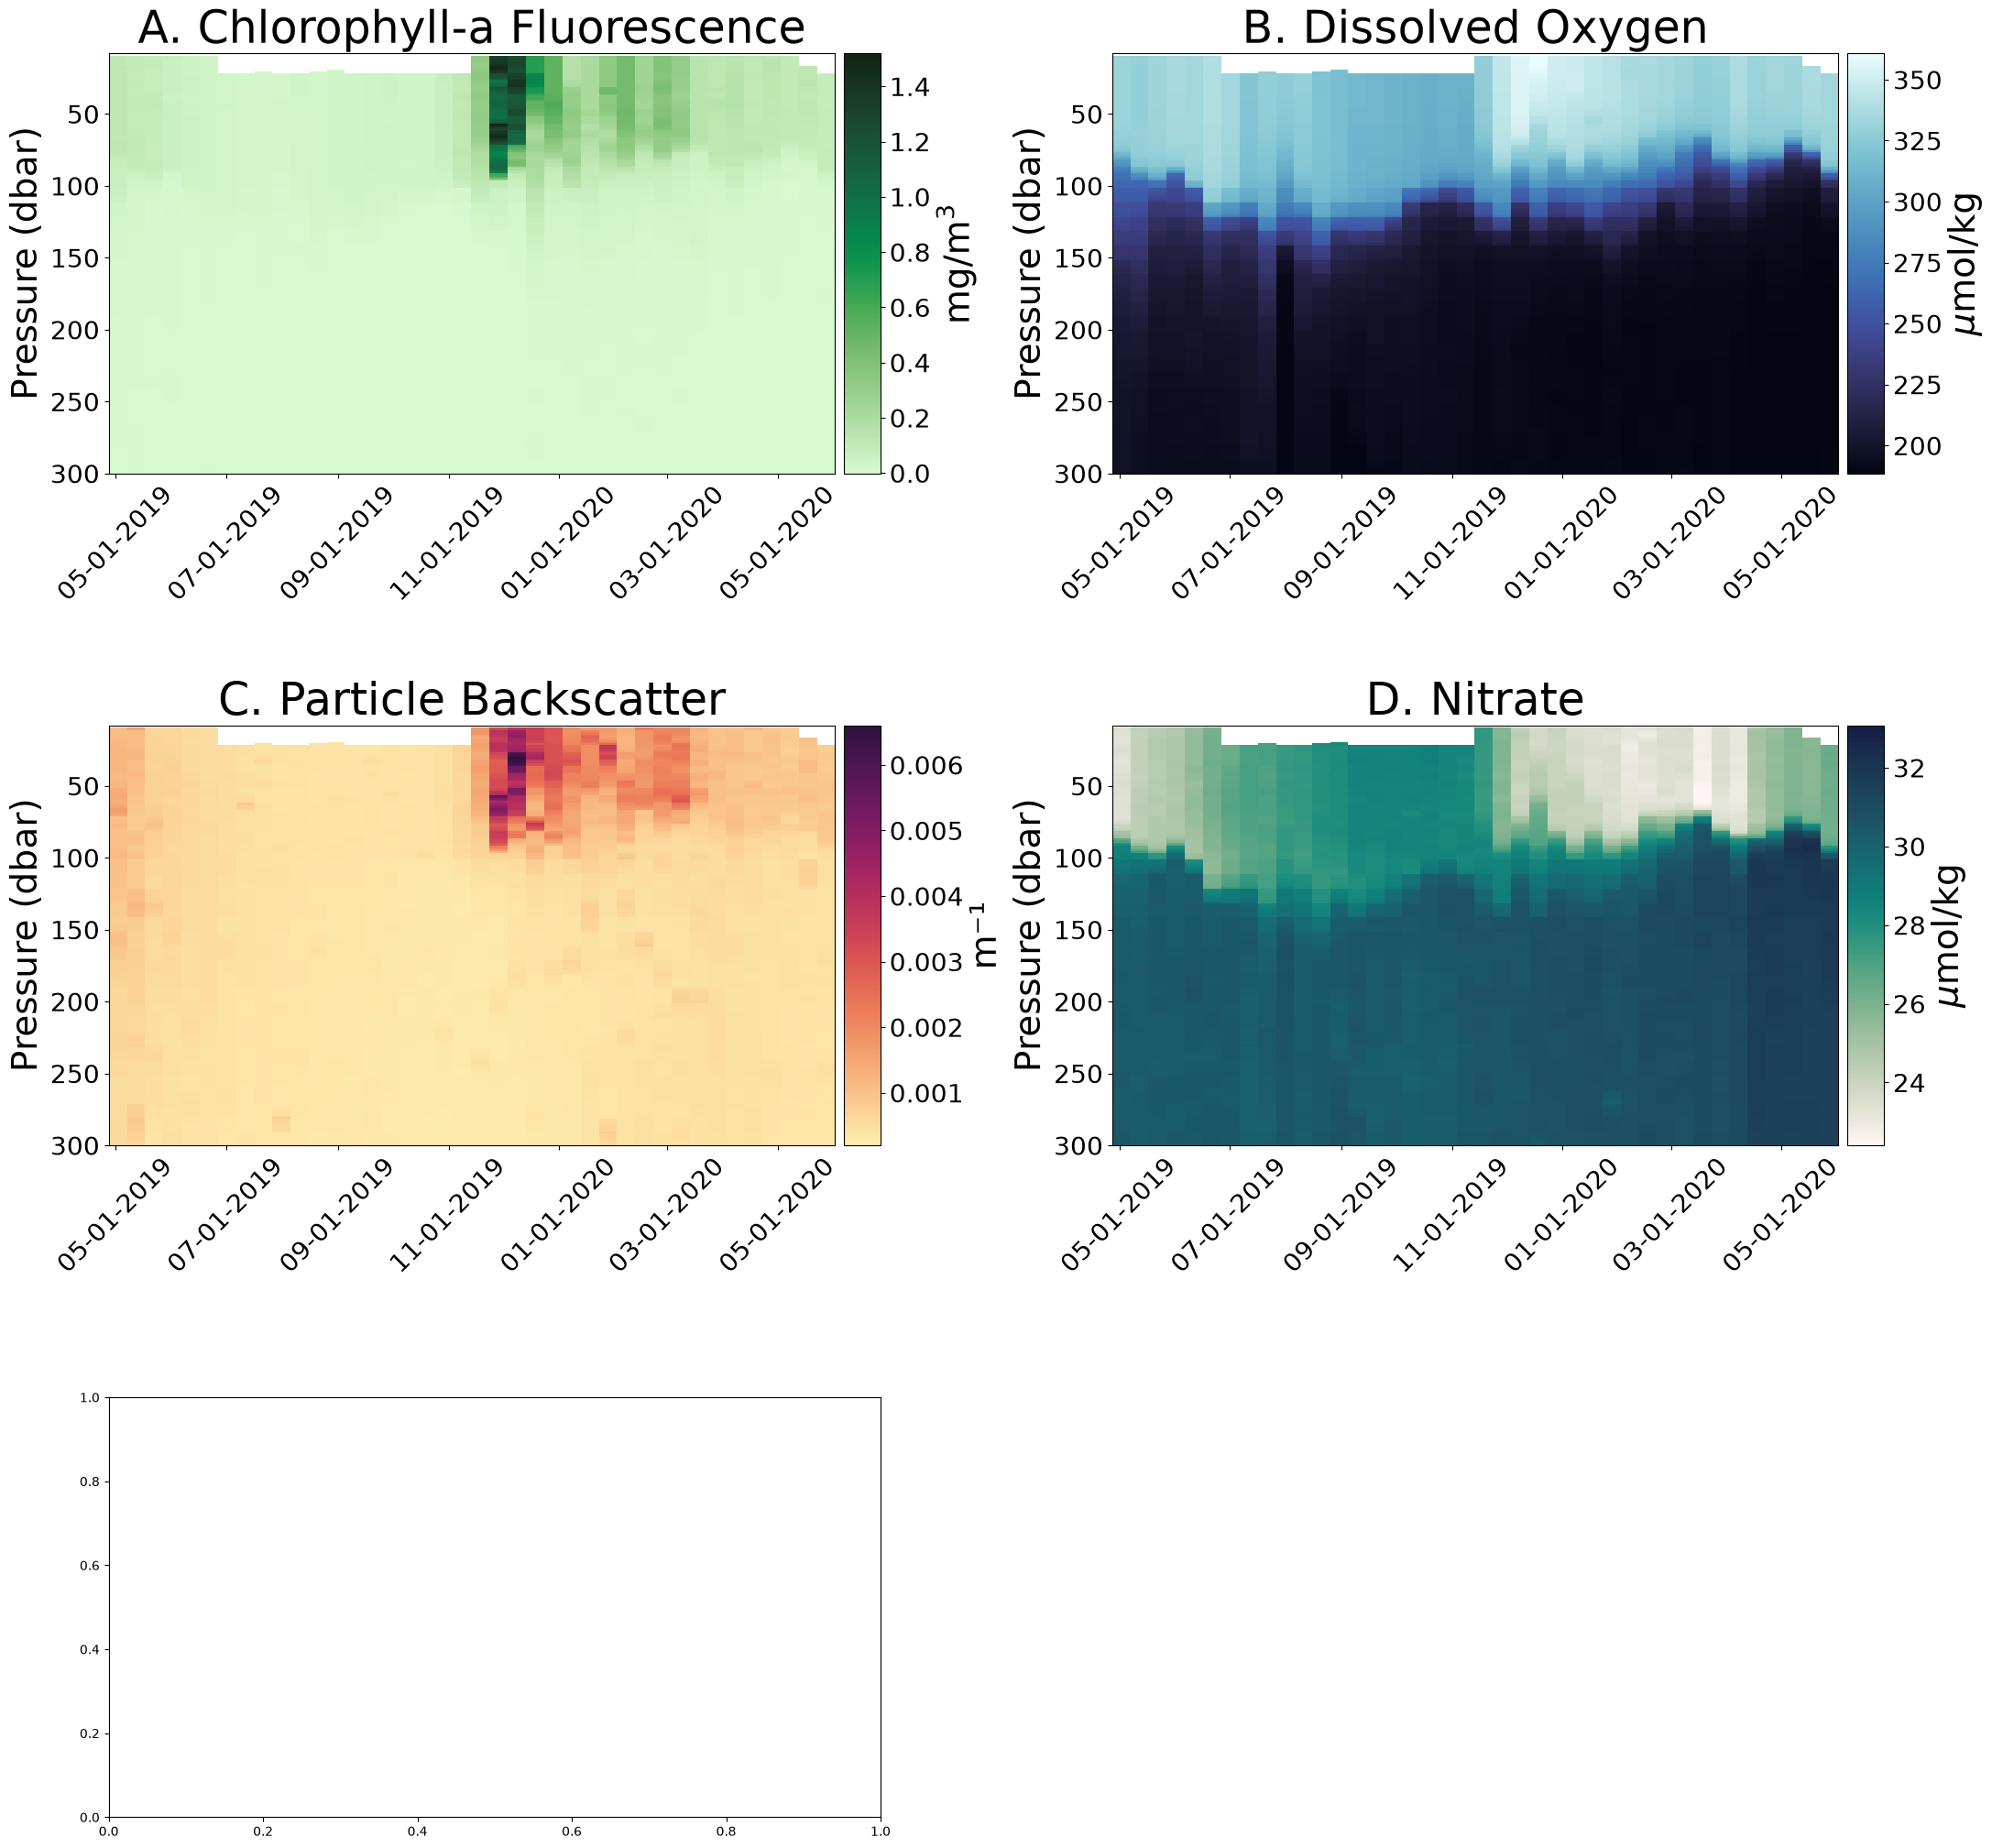

In [14]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime, timedelta

def section(ax_position,variable, df1, title, cbarlab, color, WMOID=5905379, tick_size = 20, label_size=28, title_size=35):

    # df_ts = df_ts[df_ts['season_1'].isin([season_1])]
    # df_ts = df_ts[df_ts['season_2'].isin([season_2])]
    df2 = df1[df1['WMOID'].isin([WMOID])]
    
    # regridding data (from oneargopy code) -----------
    
    time_values = pd.to_datetime(df2['DATE']).values
    pres_values = df2['PRES'].values
    param_values = df2[variable].values
    # Remove NaN values
    valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
    time_values = time_values[valid_indices]
    pres_values = pres_values[valid_indices]
    param_values = param_values[valid_indices]
    # Convert time_values to float because it makes gridding data easier
    time_values_num = mdates.date2num(time_values)
    # Unique values for creating grids
    unique_times_num = np.unique(time_values_num)
    # Create a pressure axis with regular intervals, covering all existing values
    intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
    # intp_pres = np.arange(np.ceil(10), np.floor(2000))
    # Create grid for interpolation
    time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
    # Set param_gridded to NaN array with the same shape as the grid
    param_gridded = np.full(time_grid.shape, np.nan)
    # Create a DataFrame
    df = pd.DataFrame({
        'time': time_values_num,
        'pressure': pres_values,
        'param': param_values
    })
    # Pivot the DataFrame to create a grid
    param_gridded_df = df.pivot_table(
        index='pressure',
        columns='time',
        values='param',
        aggfunc='first'
    )
    # Create a new index that contains original and regularly spaced pressure values
    all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
    # Reindex the DataFrame to the combined depth axis
    param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
    # Perform linear interpolation to the new depth axis without extrapolation
    param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
    # Extract the values to the regularly spaced depth values
    param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
    # Assigning data to variable to graph
    param_gridded = param_gridded_df.values
    
    # plotting data -----------------
        
    ax = fig.add_subplot(ax_position)
    plot = ax.pcolormesh(time_grid, pres_grid, param_gridded, shading='auto', cmap=color)
    # plot2 = ax.plot(df2['DATE'],df2['MLP'],linewidth=3,color='white')
    
    ax.set_ylim([0, 300])
    ax.invert_yaxis()
    # Add a colorbar to show the scale of the variable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    cbar = fig.colorbar(plot, cax=cax, fraction=0.012, aspect=10, pad=0.01)
    cbar.ax.tick_params(labelsize=tick_size)
    
    # cbar.set_label(f" (µmol/kg)", size=24) # nitrate, oxy
    # cbar.set_label(f"(m\u207b\u00b9)", size=24) # backscatter
    # cbar.set_label(f'(\u00B0C)', size=24) # temp
    # cbar.set_label(f"(mg/m^3)", size=24) # chla, 
    cbar.set_label(cbarlab, size=label_size) # salinity
    
    ax.tick_params(axis='y', which='major', labelsize=tick_size)
    # X Axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', which='major', labelsize=tick_size, rotation=45)
    # Titles
    ax.set_ylim(300, 8)
    ax.set_xlabel('', fontsize=label_size)
    ax.set_ylabel('Pressure (dbar)', fontsize=label_size)

    # target_time = datetime(2014, 9, 16)
    # ax.plot([target_time, target_time], [0, 10], color='white', ls = '--', linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)

    # target_time = datetime(2015, 1, 16)
    # ax.plot([target_time, target_time], [0, 10], color='white', ls = '--',linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)

    # target_time = datetime(2015, 4, 27)
    # ax.plot([target_time, target_time], [0, 10], color='white',ls = '--', linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)


    ax.set_title(title, fontsize=title_size) # salinity

    # add save path
    # fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_section_{variable}_2014-15.png', dpi=300, transparent=True, bbox_inches='tight') #uncomment for lilah
    # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/float_trajectories_{season}.png') #uncomment for stevie

fig = plt.figure(figsize=(25,25))
plt.subplots_adjust(hspace = 0.6, wspace=0.30)

section(ax_position = 321,  df1=subset_df, title = 'A. Chlorophyll-a Fluorescence', variable='CHLA_ADJUSTED', cbarlab = f'mg/m$^3$',color = 'cmo.algae')
section(ax_position = 322,  df1=subset_df, title = 'B. Dissolved Oxygen', variable='DOXY_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.ice')
section(ax_position = 323,  df1=subset_df,  title = 'C. Particle Backscatter', variable='BBP700_ADJUSTED', cbarlab = f"m\u207b\u00b9",color = 'cmo.matter')
section(ax_position = 324,  df1=subset_df, title = 'D. Nitrate', variable='NITRATE_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.tempo')
section(ax_position = 325,  df1=subset_df, title = 'E. Temperature', variable='CT', cbarlab = f'\u00B0C',color = 'cmo.thermal')
section(ax_position = 326,  df1=subset_df, title = 'F. Salinity', variable='SA', cbarlab = 'PSU',color = 'cmo.haline')

fig.suptitle('Float 5905102 Section Plots', fontsize = 45, y=0.94)

# fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_sections_all_nitrate_2014-15.png',dpi=300, transparent=True,  bbox_inches='tight')

<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_28575/2202726196.py:107: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 322,  df1=subset_df, df2=float_data, title = 'B. Dissolved Oxygen', variable='DOXY_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.ice')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_28575/2202726196.py:109: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 324,  df1=subset_df, df2=float_data, title = 'D. Nitrate', variable='NITRATE_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.tempo')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_28575/2202726196.py:107: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 322,  df1=subset_df, df2=float_data, title = 'B. Dissolved Oxyge

ValueError: min() iterable argument is empty

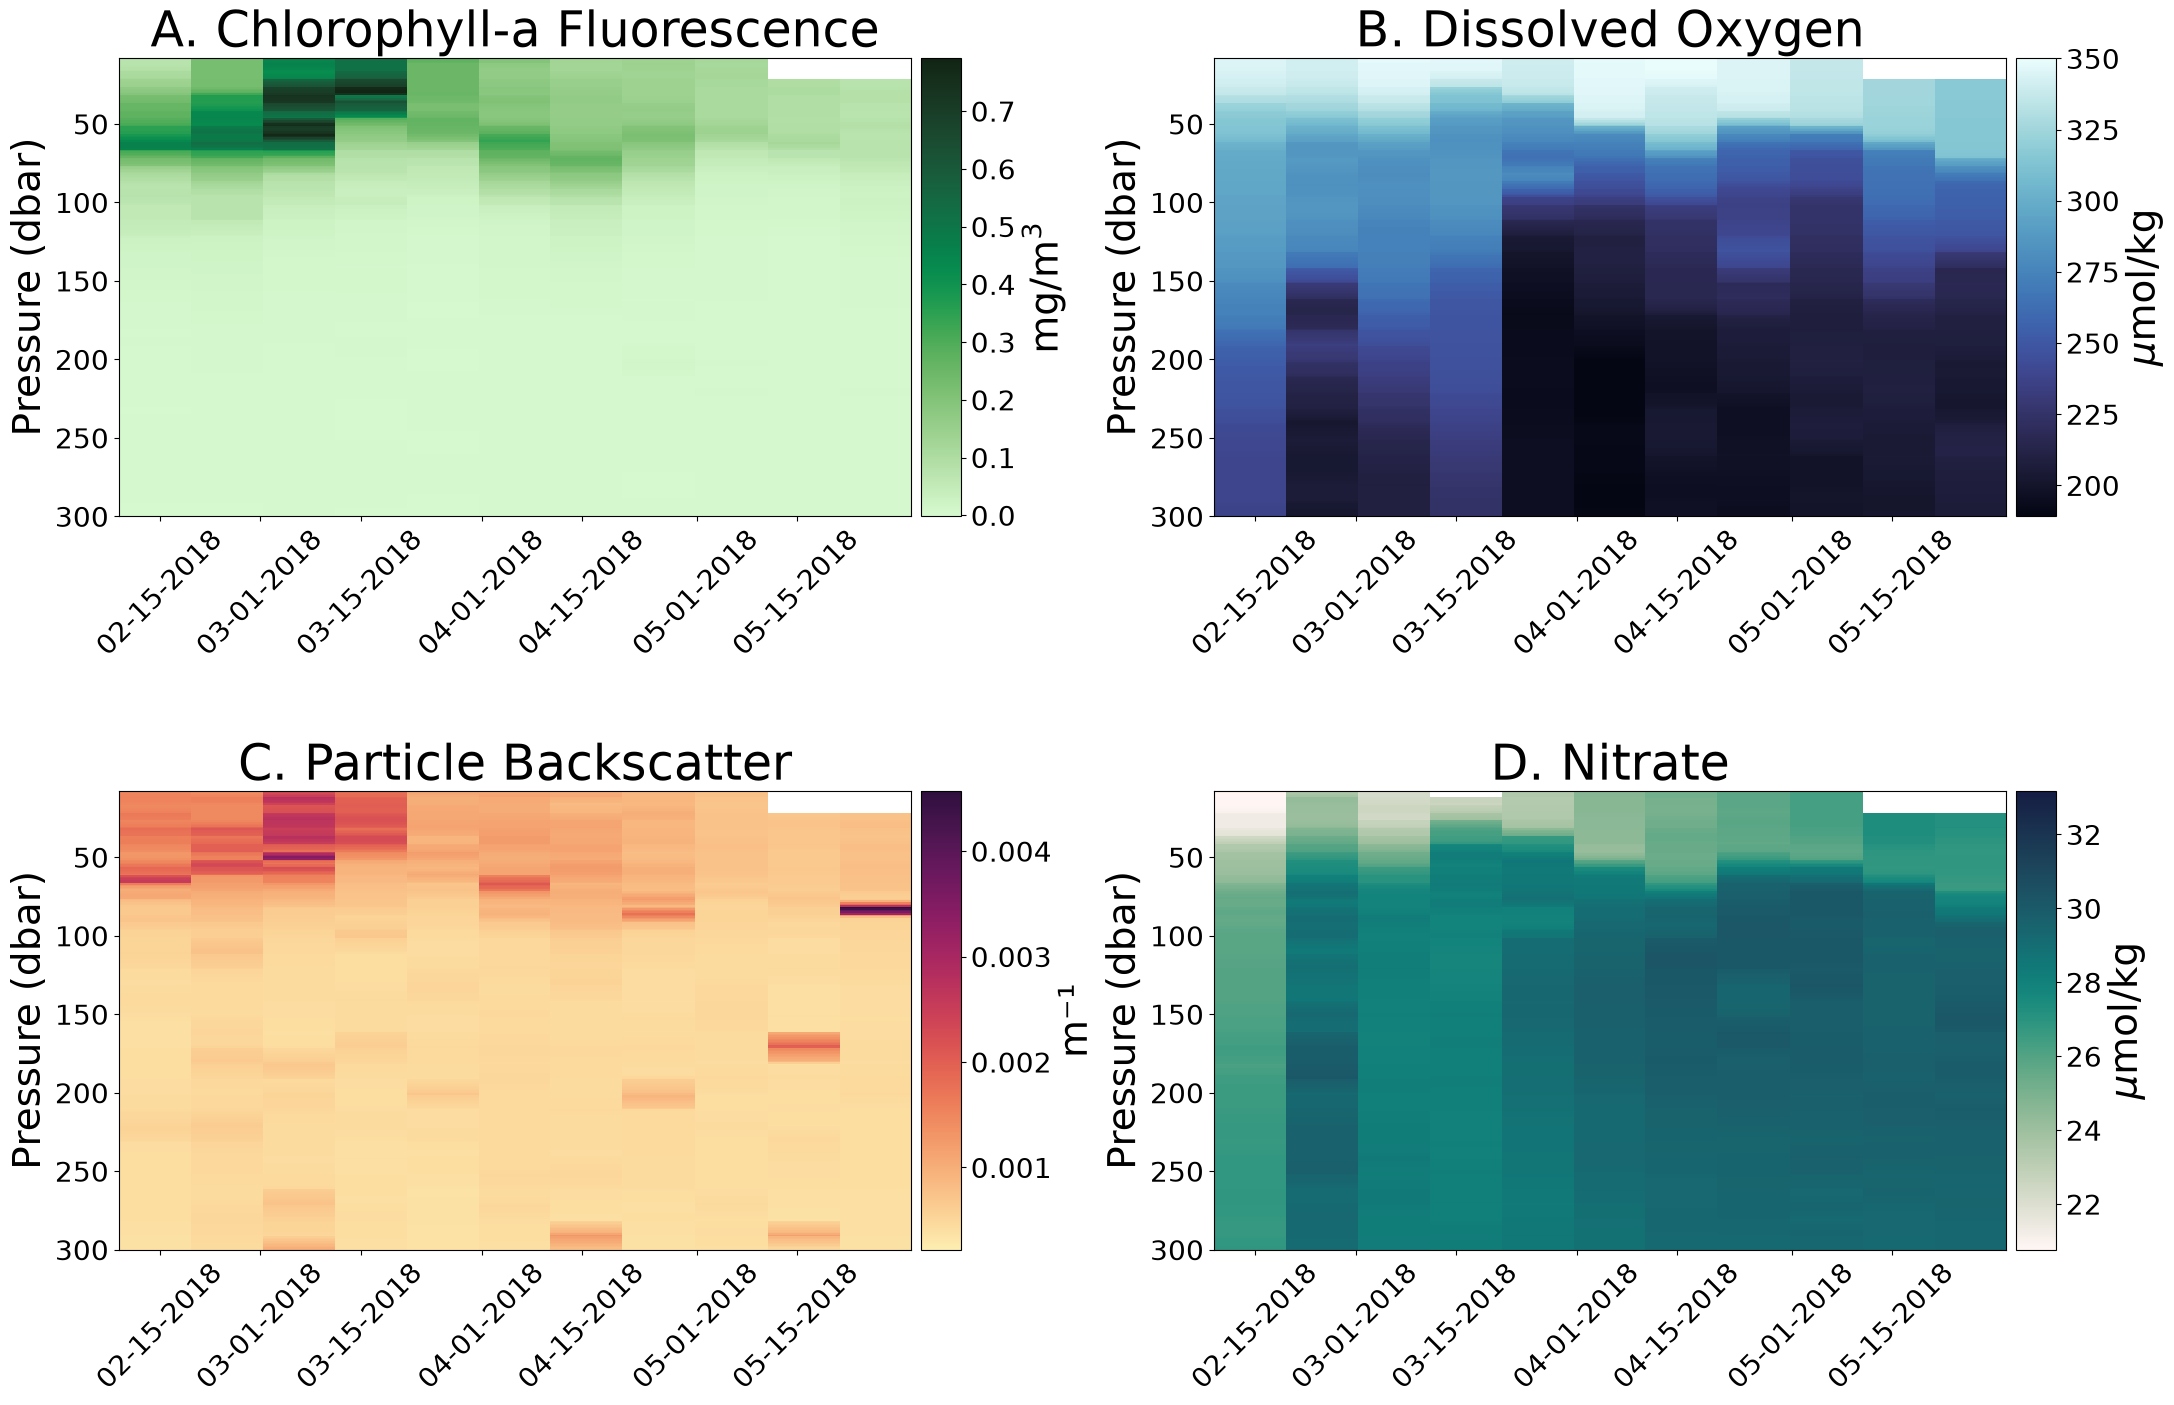

In [23]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime, timedelta

def section(ax_position,variable, df1, df2, title, cbarlab, color, WMOID=5905379, tick_size = 20, label_size=28, title_size=35):

    # df_ts = df_ts[df_ts['season_1'].isin([season_1])]
    # df_ts = df_ts[df_ts['season_2'].isin([season_2])]
    df2 = df1[df1['WMOID'].isin([WMOID])]
    
    # regridding data (from oneargopy code) -----------
    
    time_values = pd.to_datetime(df2['DATE']).values
    pres_values = df2['PRES'].values
    param_values = df2[variable].values
    # Remove NaN values
    valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
    time_values = time_values[valid_indices]
    pres_values = pres_values[valid_indices]
    param_values = param_values[valid_indices]
    # Convert time_values to float because it makes gridding data easier
    time_values_num = mdates.date2num(time_values)
    # Unique values for creating grids
    unique_times_num = np.unique(time_values_num)
    # Create a pressure axis with regular intervals, covering all existing values
    intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
    # Create grid for interpolation
    time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
    # Set param_gridded to NaN array with the same shape as the grid
    param_gridded = np.full(time_grid.shape, np.nan)
    # Create a DataFrame
    df = pd.DataFrame({
        'time': time_values_num,
        'pressure': pres_values,
        'param': param_values
    })
    # Pivot the DataFrame to create a grid
    param_gridded_df = df.pivot_table(
        index='pressure',
        columns='time',
        values='param',
        aggfunc='first'
    )
    # Create a new index that contains original and regularly spaced pressure values
    all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
    # Reindex the DataFrame to the combined depth axis
    param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
    # Perform linear interpolation to the new depth axis without extrapolation
    param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
    # Extract the values to the regularly spaced depth values
    param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
    # Assigning data to variable to graph
    param_gridded = param_gridded_df.values
    
    # plotting data -----------------
        
    ax = fig.add_subplot(ax_position)
    plot = ax.pcolormesh(time_grid, pres_grid, param_gridded, shading='auto', cmap=color)
    # plot2 = ax.plot(df2['DATE'],df2['MLP'],linewidth=3,color='white')
    
    ax.set_ylim([0, 300])
    ax.invert_yaxis()
    # Add a colorbar to show the scale of the variable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    cbar = fig.colorbar(plot, cax=cax, fraction=0.012, aspect=10, pad=0.01)
    cbar.ax.tick_params(labelsize=tick_size)
    
    # cbar.set_label(f" (µmol/kg)", size=24) # nitrate, oxy
    # cbar.set_label(f"(m\u207b\u00b9)", size=24) # backscatter
    # cbar.set_label(f'(\u00B0C)', size=24) # temp
    # cbar.set_label(f"(mg/m^3)", size=24) # chla, 
    cbar.set_label(cbarlab, size=label_size) # salinity
    
    ax.tick_params(axis='y', which='major', labelsize=tick_size)
    # X Axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', which='major', labelsize=tick_size, rotation=45)
    # Titles
    ax.set_ylim(300, 8)
    ax.set_xlabel('', fontsize=label_size)
    ax.set_ylabel('Pressure (dbar)', fontsize=label_size)

    # target_time = datetime(2014, 9, 16)
    # ax.plot([target_time, target_time], [0, 10], color='white', ls = '--', linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)

    # target_time = datetime(2015, 1, 16)
    # ax.plot([target_time, target_time], [0, 10], color='white', ls = '--',linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)

    # target_time = datetime(2015, 4, 27)
    # ax.plot([target_time, target_time], [0, 10], color='white',ls = '--', linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)


    ax.set_title(title, fontsize=title_size) # salinity

    # add save path
    # fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_section_{variable}_2014-15.png', dpi=300, transparent=True, bbox_inches='tight') #uncomment for lilah
    # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/float_trajectories_{season}.png') #uncomment for stevie

fig = plt.figure(figsize=(25,25))
plt.subplots_adjust(hspace = 0.6, wspace=0.30)

section(ax_position = 321,  df1=subset_df, df2=float_data, title = 'A. Chlorophyll-a Fluorescence', variable='CHLA_ADJUSTED', cbarlab = f'mg/m$^3$',color = 'cmo.algae')
section(ax_position = 322,  df1=subset_df, df2=float_data, title = 'B. Dissolved Oxygen', variable='DOXY_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.ice')
section(ax_position = 323,  df1=subset_df, df2=float_data, title = 'C. Particle Backscatter', variable='BBP700_ADJUSTED', cbarlab = f"m\u207b\u00b9",color = 'cmo.matter')
section(ax_position = 324,  df1=subset_df, df2=float_data, title = 'D. Nitrate', variable='NITRATE_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.tempo')
section(ax_position = 325,  df1=subset_df, df2=float_data, title = 'E. Temperature', variable='CT', cbarlab = f'\u00B0C',color = 'cmo.thermal')
section(ax_position = 326,  df1=subset_df, df2=float_data, title = 'F. Salinity', variable='AS', cbarlab = 'PSU',color = 'cmo.haline')

fig.suptitle('Float 5905379 Section Plots', fontsize = 45, y=0.94)

# fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_sections_all_nitrate_2014-15.png',dpi=300, transparent=True,  bbox_inches='tight')

In [19]:
# # Condition 1: July-Dec 2014
# cond1 = (df_new['year'] == 2017) & (df_new['month'] >= 5)

# # Condition 2: Jan-June 2015
# cond2 = (df_new['year'] == 2018) & (df_new['month'] <= 5)


# # Combine them with "OR" (|)
# subset_df = df_new[cond1 | cond2]


float_data = df_new[df_new['WMOID'].isin([5905100])]
float_data

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,DOWNWELLING_PAR_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
691956,691956,692936,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.237315,0.123812,1027.377728,27.355896,7.272865e-08,100.480000
691957,691957,692937,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.237314,0.124739,1027.387688,27.355845,7.121780e-08,100.480000
691958,691958,692938,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.237918,0.123501,1027.393101,27.356396,3.093085e-08,100.480000
691959,691959,692939,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.238319,0.122676,1027.396707,27.356761,4.802576e-07,100.480000
691960,691960,692940,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.238311,0.123342,1027.403862,27.356719,4.418556e-07,100.480000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734692,734692,735672,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.866376,0.425743,1035.313551,27.843282,6.101186e-08,67.450005
734693,734693,735673,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.864606,0.379080,1035.774818,27.844613,4.916725e-07,67.450005
734694,734694,735674,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.864133,0.339785,1036.235575,27.846526,3.427100e-07,67.450005
734695,734695,735675,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.863132,0.302975,1036.692519,27.847853,2.552830e-07,67.450005


<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_28575/2900011386.py:107: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 322,  df1=df_new, df2=float_data, title = 'B. Dissolved Oxygen', variable='DOXY_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.ice')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_28575/2900011386.py:109: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 324,  df1=df_new, df2=float_data, title = 'D. Nitrate', variable='NITRATE_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.tempo')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_28575/2900011386.py:107: SyntaxWarning: invalid escape sequence '\m'
  section(ax_position = 322,  df1=df_new, df2=float_data, title = 'B. Dissolved Oxygen', varia

ValueError: min() iterable argument is empty

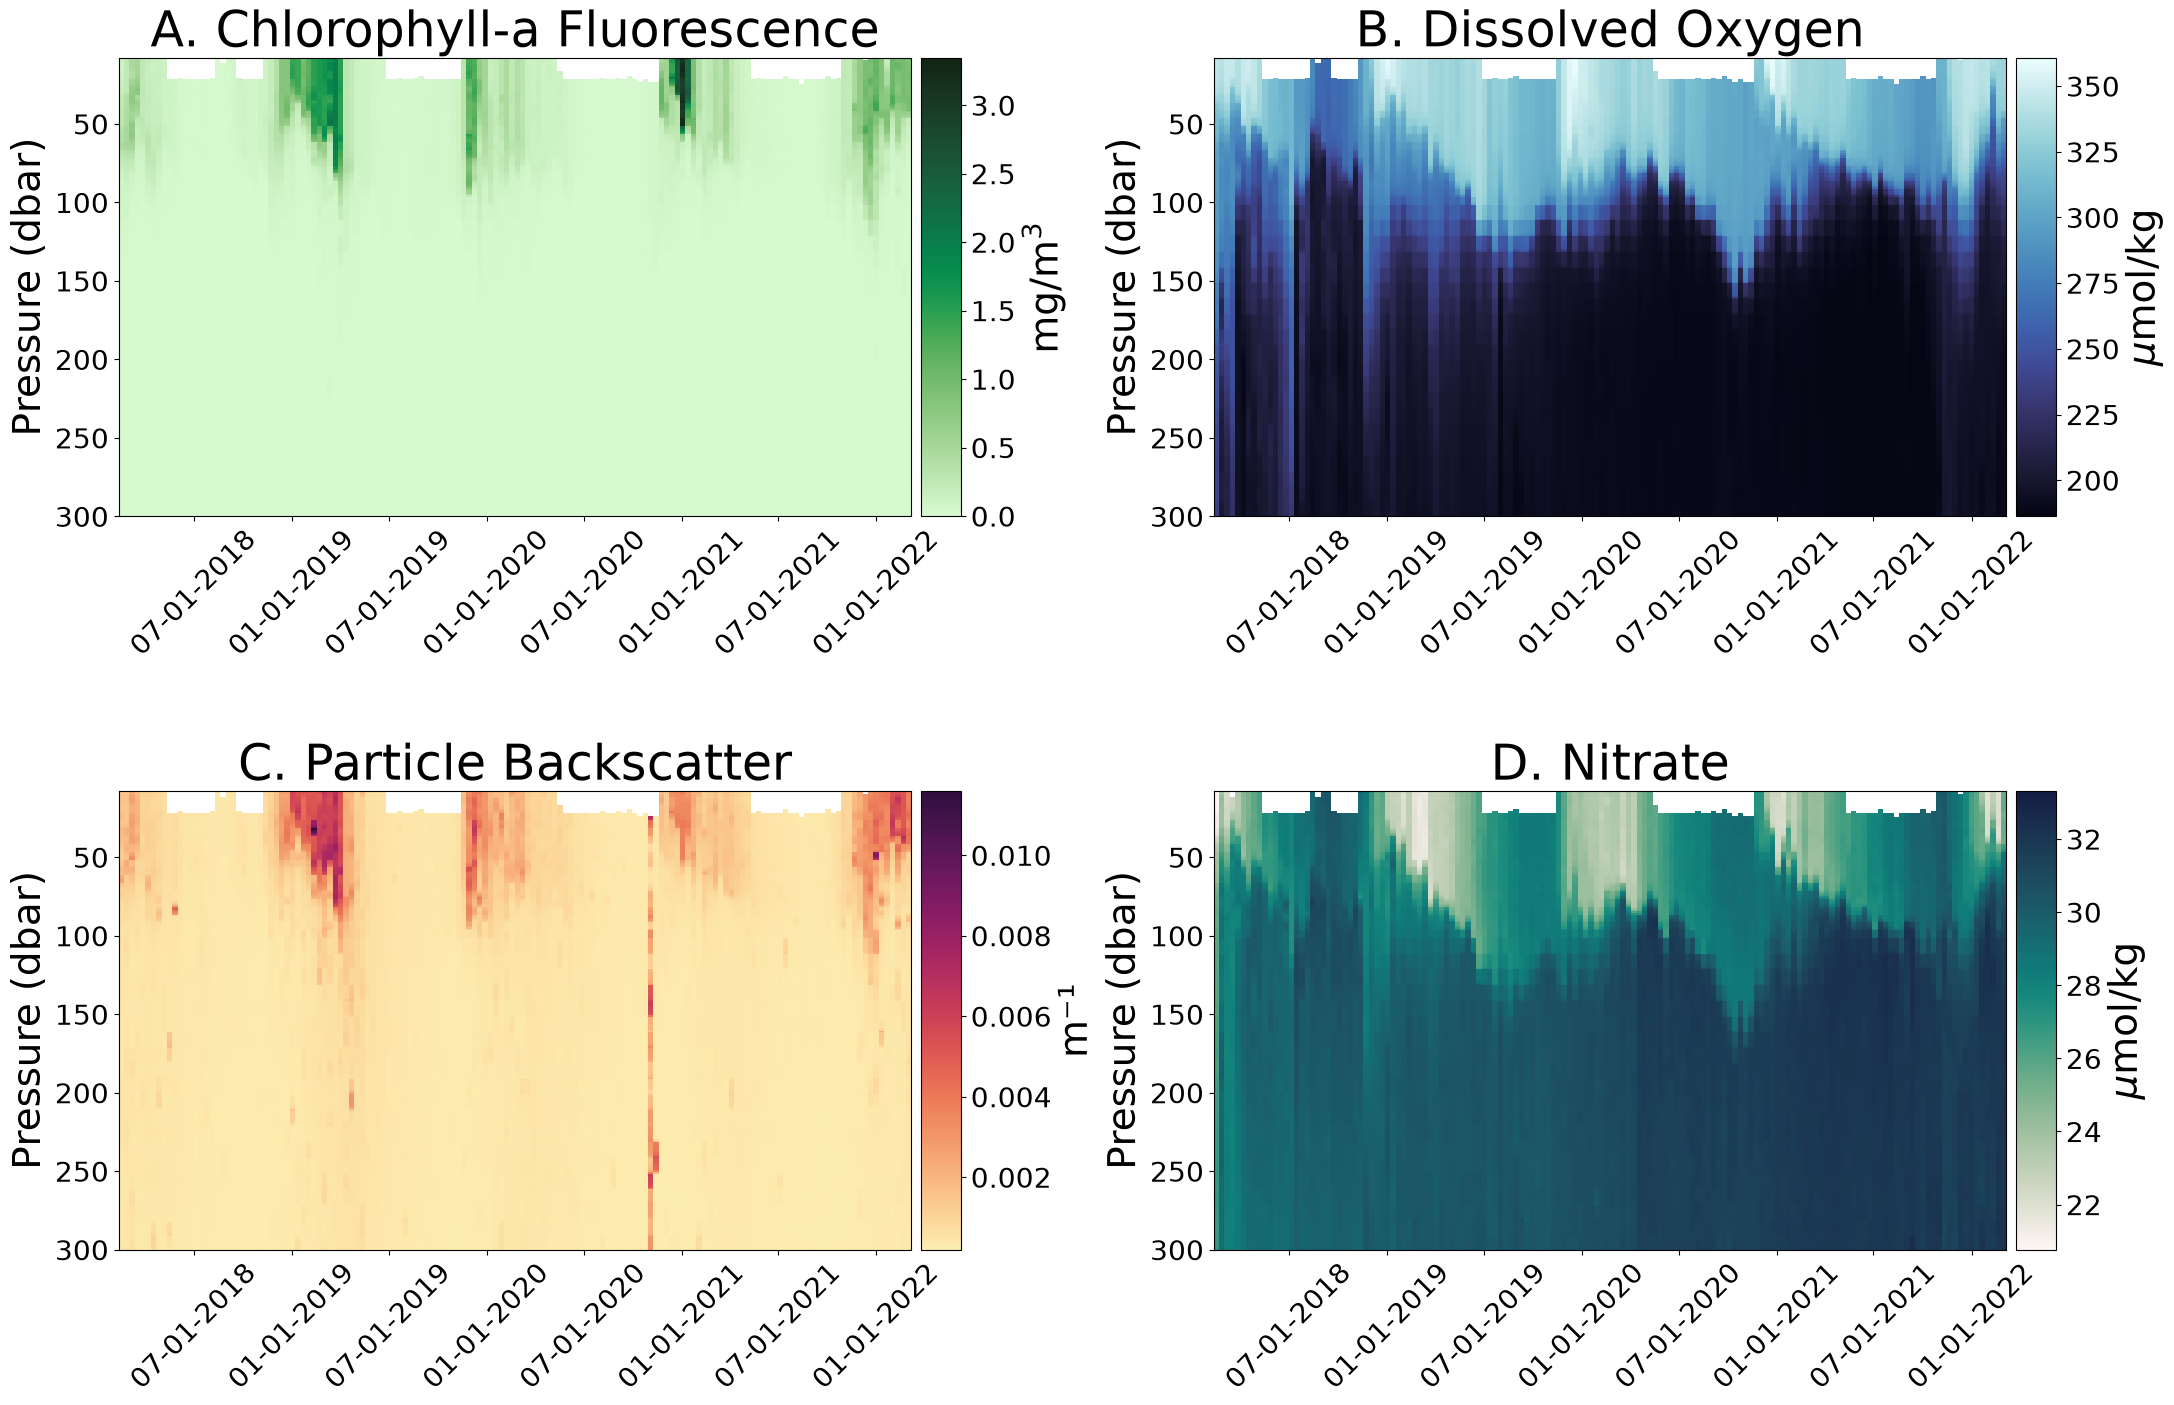

In [20]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime, timedelta

def section(ax_position,variable, df1, df2, title, cbarlab, color, WMOID=5905379, tick_size = 20, label_size=28, title_size=35):

    # df_ts = df_ts[df_ts['season_1'].isin([season_1])]
    # df_ts = df_ts[df_ts['season_2'].isin([season_2])]
    df2 = df1[df1['WMOID'].isin([WMOID])]
    
    # regridding data (from oneargopy code) -----------
    
    time_values = pd.to_datetime(df2['DATE']).values
    pres_values = df2['PRES'].values
    param_values = df2[variable].values
    # Remove NaN values
    valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
    time_values = time_values[valid_indices]
    pres_values = pres_values[valid_indices]
    param_values = param_values[valid_indices]
    # Convert time_values to float because it makes gridding data easier
    time_values_num = mdates.date2num(time_values)
    # Unique values for creating grids
    unique_times_num = np.unique(time_values_num)
    # Create a pressure axis with regular intervals, covering all existing values
    intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
    # Create grid for interpolation
    time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
    # Set param_gridded to NaN array with the same shape as the grid
    param_gridded = np.full(time_grid.shape, np.nan)
    # Create a DataFrame
    df = pd.DataFrame({
        'time': time_values_num,
        'pressure': pres_values,
        'param': param_values
    })
    # Pivot the DataFrame to create a grid
    param_gridded_df = df.pivot_table(
        index='pressure',
        columns='time',
        values='param',
        aggfunc='first'
    )
    # Create a new index that contains original and regularly spaced pressure values
    all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
    # Reindex the DataFrame to the combined depth axis
    param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
    # Perform linear interpolation to the new depth axis without extrapolation
    param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
    # Extract the values to the regularly spaced depth values
    param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
    # Assigning data to variable to graph
    param_gridded = param_gridded_df.values
    
    # plotting data -----------------
        
    ax = fig.add_subplot(ax_position)
    plot = ax.pcolormesh(time_grid, pres_grid, param_gridded, shading='auto', cmap=color)
    # plot2 = ax.plot(df2['DATE'],df2['MLP'],linewidth=3,color='white')
    
    ax.set_ylim([0, 300])
    ax.invert_yaxis()
    # Add a colorbar to show the scale of the variable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    cbar = fig.colorbar(plot, cax=cax, fraction=0.012, aspect=10, pad=0.01)
    cbar.ax.tick_params(labelsize=tick_size)
    
    # cbar.set_label(f" (µmol/kg)", size=24) # nitrate, oxy
    # cbar.set_label(f"(m\u207b\u00b9)", size=24) # backscatter
    # cbar.set_label(f'(\u00B0C)', size=24) # temp
    # cbar.set_label(f"(mg/m^3)", size=24) # chla, 
    cbar.set_label(cbarlab, size=label_size) # salinity
    
    ax.tick_params(axis='y', which='major', labelsize=tick_size)
    # X Axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', which='major', labelsize=tick_size, rotation=45)
    # Titles
    ax.set_ylim(300, 8)
    ax.set_xlabel('', fontsize=label_size)
    ax.set_ylabel('Pressure (dbar)', fontsize=label_size)

    # target_time = datetime(2014, 9, 16)
    # ax.plot([target_time, target_time], [0, 10], color='white', ls = '--', linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)

    # target_time = datetime(2015, 1, 16)
    # ax.plot([target_time, target_time], [0, 10], color='white', ls = '--',linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)

    # target_time = datetime(2015, 4, 27)
    # ax.plot([target_time, target_time], [0, 10], color='white',ls = '--', linewidth=2)
    # ax.axvline(x=target_time, color='white',  ls = '--',linewidth=3)


    ax.set_title(title, fontsize=title_size) # salinity

    # add save path
    # fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_section_{variable}_2014-15.png', dpi=300, transparent=True, bbox_inches='tight') #uncomment for lilah
    # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/float_trajectories_{season}.png') #uncomment for stevie

fig = plt.figure(figsize=(25,25))
plt.subplots_adjust(hspace = 0.6, wspace=0.30)

section(ax_position = 321,  df1=df_new, df2=float_data, title = 'A. Chlorophyll-a Fluorescence', variable='CHLA_ADJUSTED', cbarlab = f'mg/m$^3$',color = 'cmo.algae')
section(ax_position = 322,  df1=df_new, df2=float_data, title = 'B. Dissolved Oxygen', variable='DOXY_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.ice')
section(ax_position = 323,  df1=df_new, df2=float_data, title = 'C. Particle Backscatter', variable='BBP700_ADJUSTED', cbarlab = f"m\u207b\u00b9",color = 'cmo.matter')
section(ax_position = 324,  df1=df_new, df2=float_data, title = 'D. Nitrate', variable='NITRATE_ADJUSTED', cbarlab = f'$\mu$mol/kg',color = 'cmo.tempo')
section(ax_position = 325,  df1=df_new, df2=float_data, title = 'E. Temperature', variable='TEMP_ADJUSTED', cbarlab = f'\u00B0C',color = 'cmo.thermal')
section(ax_position = 326,  df1=df_new, df2=float_data, title = 'F. Salinity', variable='PSAL_ADJUSTED', cbarlab = 'PSU',color = 'cmo.haline')

fig.suptitle('Float 5905100 Section Plots', fontsize = 45, y=0.94)

# fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_sections_all_nitrate_2014-15.png',dpi=300, transparent=True,  bbox_inches='tight')